example

In [2]:
# 3.1
import numpy as np
import scipy.linalg as la

A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])

b = np.array([1237, 1941, 2417, 711, 1177, 475])
A_plus = la.inv((A.T @ A)) @ A.T

la.lstsq(A, b)

(array([1236., 1943., 2416.]),
 np.float64(35.00000000000276),
 3,
 array([2., 2., 1.]))

array([ 2.17571993,  2.67041339, -0.23844394])

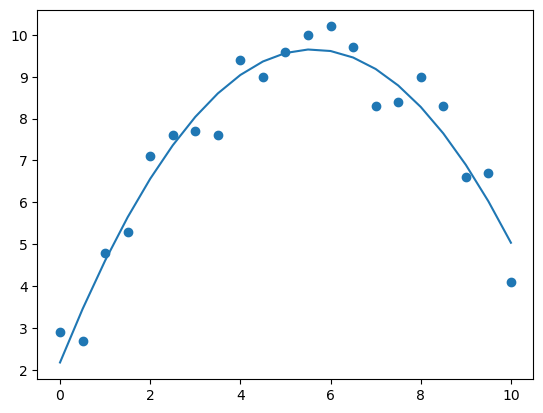

In [3]:
# 3.2
from matplotlib import pyplot as plt
from numpy.polynomial import Polynomial

ts = np.linspace(0, 10, 21)
ys = [2.9, 2.7, 4.8, 5.3, 7.1, 7.6, 7.7, 7.6, 9.4, 9, 9.6, 10, 10.2, 9.7, 8.3, 8.4, 9, 8.3, 6.6, 6.7, 4.1]
plt.scatter(ts, ys)
p = Polynomial(la.lstsq(np.vander(ts, N=3, increasing=True), ys)[0])
plt.plot(ts, p(ts))
p.coef

In [4]:
# 3.3
A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])
b = np.array([1237, 1941, 2417, 711, 1177, 475])

x = la.solve(A.T @ A, A.T @ b, assume_a='pos')
r = b - A @ x

print(la.norm(r, ord=2) ** 2)

L = la.cholesky(A.T @ A, lower=True)
y = la.solve_triangular(L, A.T @ b, lower=True)
la.solve_triangular(L.T, y)



35.0


array([1236., 1943., 2416.])

In [5]:
# 3.4
A.T @ r
A_plus = la.inv((A.T @ A)) @ A.T
P = A @ A_plus
P

P_orthogonal = np.eye(6) - P
P_orthogonal
np.allclose(r, P_orthogonal @ b)
np.allclose(A @ x, P @ b)

True

In [6]:
# 3.5
la.norm(A, ord=2)
la.norm(A_plus, ord=2)
# A @ x, P @ b
# la.norm(A @ x, ord=2) / la.norm(b, ord=2)
# np.acos(_)


np.float64(1.0)

In [ ]:
# 3.14
A_bottom = A[3:]
A_bottom[:, :2]
x = la.lstsq(A_bottom[:, :2], b[3:])[0]

b[3:] - A_bottom[:, :2] @ x

la.lstsq(A_bottom, b[3:])


(array([-629.33333333,   78.66666667,  550.66666667]),
 array([], dtype=float64),
 2,
 array([1.73205081e+00, 1.73205081e+00, 2.30949614e-17]))

In [ ]:
# 3.15
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
])

la.svd(A)

array([2.54624074e+01, 1.29066168e+00, 1.84466178e-15])

In [22]:
# 3.16
U, D, V = la.svd(A_bottom)
V = V.T

x = np.dot(U[:, 0], b[3:]) / D[0] * V[:, 0] + np.dot(U[:, 1], b[3:]) / D[1] * V[:, 1]
x

array([-629.33333333,   78.66666667,  550.66666667])

In [28]:
A = np.array([
    [2, -1, 1],
    [1, 0, 1],
    [3, -1, 4],
])

_, D, _ = la.svd(A)
np.linalg.cond(A, p=2) # np.float64(17.492977713805708)
D.max() / D.min()
la.norm(A, ord=2)
D.max()



np.float64(5.722926953325028)

In [ ]:
# 3.18
A = np.array([
    [.913, .659],
    [.78, .563],
    [.457, .33],
])

la.svd(A)

(array([[-0.7105806 , -0.26630886, -0.65127168],
        [-0.60706736, -0.23592311,  0.75882113],
        [-0.35573083,  0.93456935,  0.00597497]]),
 array([1.58460342e+00, 1.05619406e-04]),
 array([[-0.81082851, -0.5852838 ],
        [-0.5852838 ,  0.81082851]]))

In [34]:
# 3.19
A = np.array([
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])
U, d, V = la.svd(A)

d[:2] = 1 / d[:2]
d[2] = 0
A_plus = V.T @ np.diag(d) @ U.T
b = np.array([711, 1177, 475])
A_plus @ b


array([-629.33333333,   78.66666667,  550.66666667])

In [53]:
# 3.21
A = np.array([-2, -1, 3]).reshape(3, 1)
b = np.array([-1, 3, -2])
U, d, V = la.svd(A)
d[0] = 1/ d[0]
U, d, V

# solve by svd
D = np.zeros((len(V), len(U)))
np.fill_diagonal(D, d)
x1 = V.T @ D @ U.T @ b
x1 # -.5

# solve by lstsq
la.lstsq(A, b)

# exchange t and y
Y = b.reshape(3, 1)
T = A
la.lstsq(Y, T)

# total least squares
A_augment = np.hstack([A, b.reshape(-1, 1)])
_, _ , V = la.svd(A_augment)
V.T[-1]


array([-0.70710678, -0.70710678])

exercises

In [ ]:
# 3.1
# (a)
A = np.array([
    [1, 10],
    [1, 15],
    [1, 20],
])
b = np.array([11.6, 11.85, 12.25])
# (b)
la.solve(A[:2], b[:2]) # [11.1 ,  0.05]
la.solve(A[1:], b[1:]) # [10.65,  0.08]
la.solve(A[[0, 2]], b[[0, 2]]) # [10.95 ,  0.065]


array([10.95 ,  0.065])